Machine Learning: Algoritmo KNN  

# **Intro Teoría KNN**

* K-Nearest Neighbors (KNN) es un algoritmo de Machine Learning supervisado utilizado para problemas de clasificación y regresión. Está basado en instancias (lazy learning), lo que significa que no aprende parámetros durante el entrenamiento, sino que almacena los datos y calcula distancias durante la predicción.

El algoritmo realiza predicciones basándose en la similitud entre observaciones. Para ello calcula la distancia entre un nuevo punto de datos y los datos existentes en el conjunto de entrenamiento.

La idea principal es que observaciones similares tienden a pertenecer a la misma clase o tener valores similares.

Por ejemplo, si queremos clasificar un nuevo vino como bueno o malo, el algoritmo observará los K vinos más parecidos y asignará la clase más frecuente entre ellos.

* Qué significa K

El parámetro K representa el número de vecinos más cercanos que se utilizan para realizar la predicción.

K pequeño
El modelo es más sensible al ruido y a los outliers.

K grande
El modelo es más estable pero puede perder capacidad de capturar patrones locales.

Elegir el valor adecuado de K es fundamental para el rendimiento del modelo.


* Métricas de distancia (tu duda)

Las métricas de distancia permiten medir qué tan similares son dos observaciones.

Las más utilizadas en KNN son:

Distancia Euclídea (p = 2)
Es la distancia geométrica tradicional entre dos puntos.

Distancia Manhattan (p = 1)
Suma de las diferencias absolutas entre variables.

Distancia Minkowski
Generalización de las anteriores.

En sklearn, el parámetro p controla esto: p = 1 → Manhattan, p = 2 → Euclídea

* Clasificación vs Regresión

Clasificación

La variable objetivo pertenece a categorías o clases.

Ejemplos:

Diagnosticar diabetes / no diabetes

Clasificar vinos buenos / malos

Regresión

La variable objetivo es numérica continua.

Ejemplo:

Predecir precio de una casa

Predecir gasto de un cliente

* Cómo trabaja el algoritmo KNN

El funcionamiento del algoritmo KNN se puede resumir en cuatro pasos:

1. Selección del valor de K

Se define cuántos vecinos cercanos se utilizarán para realizar la predicción.

2. Cálculo de distancias

Se calcula la distancia entre el nuevo punto y todos los puntos del dataset.

3. Selección de los K vecinos más cercanos

Se seleccionan las K observaciones con menor distancia.

4. Predicción

En clasificación → se asigna la clase más frecuente entre los vecinos.

En regresión → se calcula la media o mediana de los vecinos.



## 1. Introducción
K-Nearest Neighbors (KNN) es un algoritmo de Machine Learning supervisado utilizado para problemas de clasificación y regresión. Este proyecto tiene como objetivo clasificar la calidad de los vinos tintos basándose en características químicas.

## 2. Teoría KNN
El algoritmo KNN predice la clase de un nuevo punto de datos basándose en la clase de sus K vecinos más cercanos. La elección del valor de K es fundamental para el rendimiento del modelo.

### Qué significa K
- **K pequeño**: Sensible al ruido y outliers.
- **K grande**: Más estable, pero puede perder patrones locales.

### Métricas de distancia
Las métricas más utilizadas en KNN son:
- **Distancia Euclídea**: <span class="katex"><span class="katex-mathml"><math xmlns="http://www.w3.org/1998/Math/MathML"><semantics><mrow><mi>p</mi><mo>=</mo><mn>2</mn></mrow><annotation encoding="application/x-tex">p = 2</annotation></semantics></math></span><span class="katex-html" aria-hidden="true"><span class="base"><span class="strut" style="height:0.625em;vertical-align:-0.1944em;"></span><span class="mord mathnormal">p</span><span class="mspace" style="margin-right:0.2778em;"></span><span class="mrel">=</span><span class="mspace" style="margin-right:0.2778em;"></span></span><span class="base"><span class="strut" style="height:0.6444em;"></span><span class="mord">2</span></span></span></span>
- **Distancia Manhattan**: <span class="katex"><span class="katex-mathml"><math xmlns="http://www.w3.org/1998/Math/MathML"><semantics><mrow><mi>p</mi><mo>=</mo><mn>1</mn></mrow><annotation encoding="application/x-tex">p = 1</annotation></semantics></math></span><span class="katex-html" aria-hidden="true"><span class="base"><span class="strut" style="height:0.625em;vertical-align:-0.1944em;"></span><span class="mord mathnormal">p</span><span class="mspace" style="margin-right:0.2778em;"></span><span class="mrel">=</span><span class="mspace" style="margin-right:0.2778em;"></span></span><span class="base"><span class="strut" style="height:0.6444em;"></span><span class="mord">1</span></span></span></span>
- **Distancia Minkowski**: Generalización de las anteriores.



# **EDA**


> * Datos sobre: busca analizar e investigar los conjuntos de datos de los que disponen y resumir sus principales características, visualización de datos para ver su comportamiento y distribución de los mismos.
> * Objetivo: Determinar las mejores variables enfocando el análisis a buscar los vinos de calidad "buena" o "mala".
> * Enfoque: Método de clasificación binaria y multiclase

## Paso 0: **Imports & Read data**


In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import plotly.express as px # Graficos tridimensionales DUDA pip install
import seaborn as sns


### **Definición de la información del conjunto de datos**

* **Creamos el DataFrame:**

In [85]:
df = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv", sep=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


> **Observaciones:**    
> Dataset con 1599 filas  
> 12 variables  
> Todas las variables son numéricas  
> No existen variables categóricas  
> La variable objetivo es quality

In [87]:
df.describe().T.round(2).sort_values("mean", ascending=False)

,count,mean,std,min,25%,50%,75%,max
total sulfur dioxide,1599.0,46.47,32.90,6.00,22.00,38.00,62.00,289.00
free sulfur dioxide,1599.0,15.87,10.46,1.00,7.00,14.00,21.00,72.00
alcohol,1599.0,10.42,1.07,8.40,9.50,10.20,11.10,14.90
fixed acidity,1599.0,8.32,1.74,4.60,7.10,7.90,9.20,15.90
quality,1599.0,5.64,0.81,3.00,5.00,6.00,6.00,8.00
pH,1599.0,3.31,0.15,2.74,3.21,3.31,3.40,4.01
residual sugar,1599.0,2.54,1.41,0.90,1.90,2.20,2.60,15.50
density,1599.0,1.00,0.00,0.99,1.00,1.00,1.00,1.00
sulphates,1599.0,0.66,0.17,0.33,0.55,0.62,0.73,2.00
volatile acidity,1599.0,0.53,0.18,0.12,0.39,0.52,0.64,1.58


> **Observaciones:**    
> La calidad del vino se encuentra entre 3 y 8  
> La media es 5.64  
> La mayoría de vinos se concentran en 5 y 6  
> Esto indica que el dataset está desbalanceado hacia calidades medias.

### **Descripción de la data inicial** 


#### **Variable target:**

In [88]:
df["quality"].unique()

array([5, 6, 7, 4, 8, 3])

> **Observaciones:** Vemos que en la columna Quality tenemos un rango de calidades que va del 3 al 8 haciendo referencia de menor a mayor calidad de cada vino.

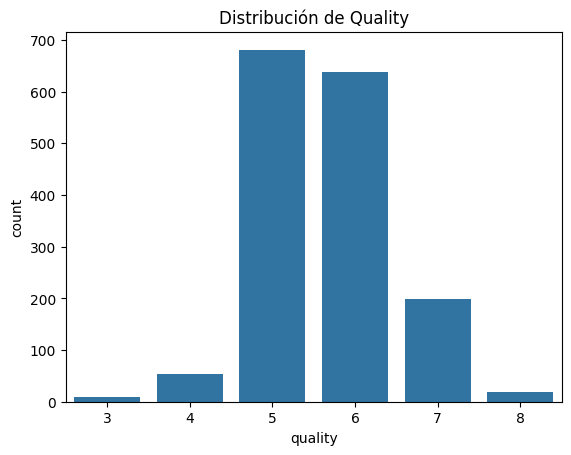

In [89]:
sns.countplot(x="quality", data=df)
plt.title("Distribución de Quality")
plt.show()

> **Observaciones:** La mayor parte de los vinos tienen calidad 5 o 6, mientras que calidades muy altas o muy bajas son poco frecuentes.

## Paso 1: **Limpieza de datos**






### **Valores NaNs**


In [90]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

**Observaciones:** No existen nulos en el df

### **Valores duplicados**

In [91]:
df.duplicated().sum()

np.int64(240)

In [92]:
df.sample(5, random_state=0)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1109,10.8,0.470,0.43,2.10,0.171,27.0,66.0,0.99820,3.17,0.76,10.8,6
1032,8.1,0.820,0.00,4.10,0.095,5.0,14.0,0.99854,3.36,0.53,9.6,5
1002,9.1,0.290,0.33,2.05,0.063,13.0,27.0,0.99516,3.26,0.84,11.7,7
487,10.2,0.645,0.36,1.80,0.053,5.0,14.0,0.99820,3.17,0.42,10.0,6
979,12.2,0.450,0.49,1.40,0.075,3.0,6.0,0.99690,3.13,0.63,10.4,5


In [93]:
df = df.drop_duplicates()

> **Observaciones:**  En datasets químicos como este los duplicados suelen representar mediciones repetidas. Por lo tanto sí deben eliminarse, porque no representan información nueva y pueden sesgar el modelo.

### **Valores a 0**

In [94]:
(df == 0).sum()

fixed acidity             0
volatile acidity          0
citric acid             118
residual sugar            0
chlorides                 0
free sulfur dioxide       0
total sulfur dioxide      0
density                   0
pH                        0
sulphates                 0
alcohol                   0
quality                   0
dtype: int64

> **Observación:** La variable citric acid tiene valores 0. Esto no es necesariamente un error, porque algunos vinos pueden tener ácido cítrico casi inexistente por lo tanto no se elimina ni se imputa.

## Paso 2: **Análisis de Variables**



> **Filtrado de la columna target por rangos:** Nueva columna 'range_quality' que contiene valor tipo object-string.
>      
> * df_binclass: buena  y mala
> * df_multiclass: low=0, medium=1, high=2

### **Defino las clasificaciones de la data**

* **Defino el dataset binario:**

In [95]:
df_binclass = df.copy()

# Separación binaria:
df_binclass["range_quality"] = df["quality"].apply(lambda x: "buena" if x >= 6 else "mala") 
df_binclass.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,range_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,mala
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,mala
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,mala
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,buena
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,mala


In [96]:
df_binclass["range_quality"].value_counts()

range_quality
buena    719
mala     640
Name: count, dtype: int64

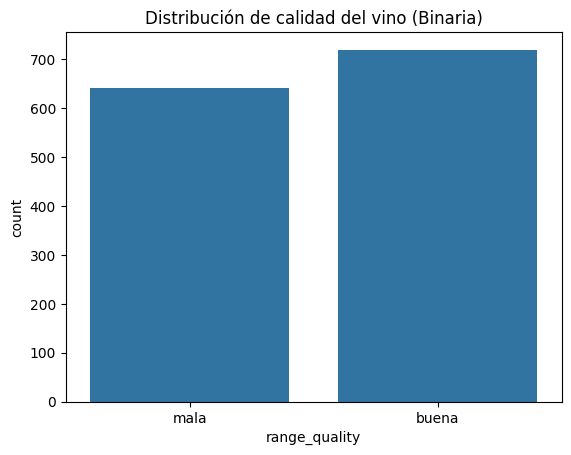

In [97]:
sns.countplot(data=df_binclass, x="range_quality")
plt.title("Distribución de calidad del vino (Binaria)")
plt.show()

> **Observación:** Las clases están relativamente balanceadas, lo cual es positivo para el modelo.

* **Defino el dataset multiclase:**

In [98]:
df_multiclass = df.copy()
# Separación multiclase:
def quality_to_label(q):
    if q <= 4:
        return 0  # low
    elif q <= 6:
        return 1  # medium
    else:
        return 2  # high

df_multiclass['target'] = df_multiclass['quality'].apply(quality_to_label)
df_multiclass.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,target
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,1


In [99]:
df_multiclass["target"].value_counts()

target
1    1112
2     184
0      63
Name: count, dtype: int64

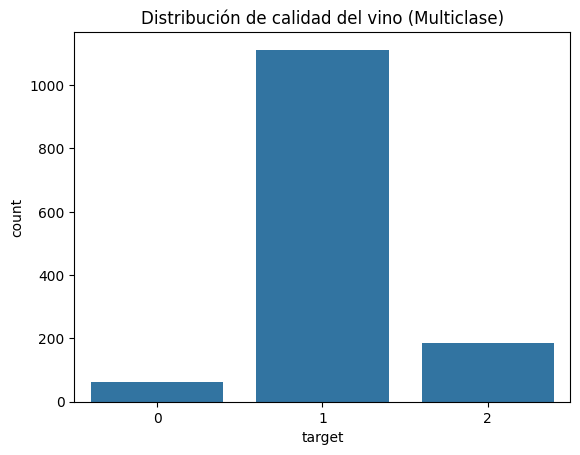

In [100]:
sns.countplot(data=df_multiclass, x="target")
plt.title("Distribución de calidad del vino (Multiclase)")
plt.show()

> **Observación:** La clase media domina el dataset, lo que puede generar sesgo del modelo.

## Paso 3: **Preparación de datos para ML**

* **Binario:**

In [101]:
X_bin = df_binclass.drop(["quality", "range_quality"], axis=1)
y_bin = df_binclass["range_quality"]

* **Multiclase:**

In [102]:
X_multi = df_multiclass.drop(["quality","target"], axis=1)
y_multi = df_multiclass["target"]

# **ML KNN**

## Paso 1: **Imports ML**

In [103]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier

# Métricas
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Paso 2: **Split data**

**Nota:** Importante: fit_transform solo en train, transform en test. Si haces fit en todo, hay data leakage (el modelo "ve" información del test durante el entrenamiento).

* **Binario:**

In [104]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bin, y_bin, test_size=0.2, random_state=42)

* **Multiclase:**

In [105]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

**Escalado de valores:**

In [106]:
scaler = StandardScaler()

X_train_b = scaler.fit_transform(X_train_b)
X_test_b = scaler.transform(X_test_b)

X_train_m = scaler.transform(X_train_m)  
X_test_m = scaler.transform(X_test_m)


## Paso 3: **Modelado y entrenamiento** 


### **Modelo base**

* **Clasificación Binaria:**

In [107]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_b, y_train_b)
y_pred_knn = knn.predict(X_test_b)

print("Accuracy KNN:", accuracy_score(y_test_b, y_pred_knn))
print(classification_report(y_test_b, y_pred_knn))

Accuracy KNN: 0.7095588235294118
              precision    recall  f1-score   support

       buena       0.70      0.74      0.72       137
        mala       0.72      0.67      0.70       135

    accuracy                           0.71       272
   macro avg       0.71      0.71      0.71       272
weighted avg       0.71      0.71      0.71       272



> **Observación:** Un accuracy alrededor de 0.70 indica que el modelo capta patrones, pero aún puede mejorar.

**Matriz de confusión para Modelo base binario:**

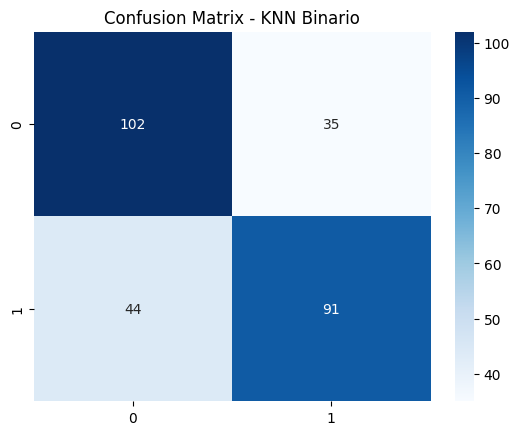

In [108]:
cm = confusion_matrix(y_test_b, y_pred_knn)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - KNN Binario")
plt.show()

* **Clasificación Multiclase:**

In [109]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_m, y_train_m)
y_pred_knn_m = knn.predict(X_test_m)

print("Accuracy KNN:", accuracy_score(y_test_m, y_pred_knn_m))
print(classification_report(y_test_m, y_pred_knn_m))

Accuracy KNN: 0.8198529411764706
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.86      0.93      0.89       223
           2       0.55      0.47      0.51        34

    accuracy                           0.82       272
   macro avg       0.47      0.47      0.47       272
weighted avg       0.78      0.82      0.80       272



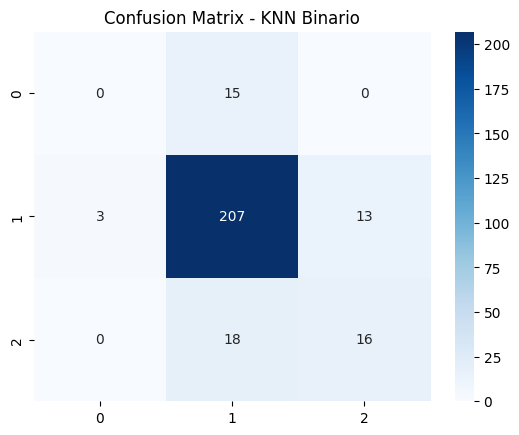

In [110]:
cm = confusion_matrix(y_test_m, y_pred_knn_m)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - KNN Binario")
plt.show()

### **Dummy Classifier**

In [111]:
dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train_b, y_train_b)

pred_dummy = dummy.predict(X_test_b)

accuracy_dummy = accuracy_score(y_test_b, pred_dummy)

print("Accuracy baseline:", accuracy_dummy)

Accuracy baseline: 0.5036764705882353


### **Comparacion de modelos**

**Defino los modelos:**

In [112]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC()
}


### **Resultados de la Clasificación Binaria**

In [113]:

results_bin = {}
for name, model in models.items():
    model.fit(X_train_b, y_train_b)
    pred = model.predict(X_test_b)
    acc = accuracy_score(y_test_b, pred)
    results_bin[name] = acc
results_bin

{'KNN': 0.7095588235294118,
 'Logistic Regression': 0.7647058823529411,
 'Decision Tree': 0.7389705882352942,
 'Random Forest': 0.7941176470588235,
 'SVM': 0.7757352941176471}

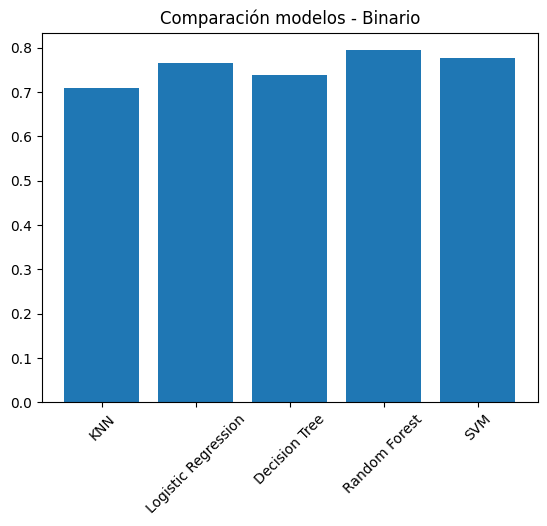

In [114]:

plt.bar(results_bin.keys(), results_bin.values())
plt.title("Comparación modelos - Binario")
plt.xticks(rotation=45)
plt.show()


### **Resultados de la Clasificación Multiclase**

In [115]:

results_multi = {}
for name, model in models.items():
    model.fit(X_train_m, y_train_m)
    pred = model.predict(X_test_m)
    acc = accuracy_score(y_test_m, pred)
    results_multi[name] = acc
results_multi

{'KNN': 0.8198529411764706,
 'Logistic Regression': 0.8382352941176471,
 'Decision Tree': 0.7830882352941176,
 'Random Forest': 0.8419117647058824,
 'SVM': 0.8639705882352942}

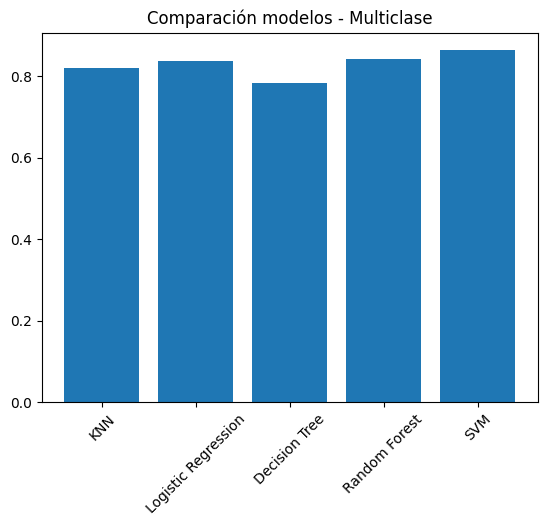

In [116]:

plt.bar(results_multi.keys(), results_multi.values())
plt.title("Comparación modelos - Multiclase")
plt.xticks(rotation=45)
plt.show()

### **Conclusiones finales**

> Se compararon distintos modelos:KNN, Logistic Regression, Decision Tree, Random Forest, SVM.  
> Resultados: Random Forest > SVM > KNN > Logistic Regression.  
>           - Los resultados muestran que Random Forest obtuvo el mejor rendimiento, lo cual es habitual en datasets tabulares.

## Paso 4: **Overfitting**

In [117]:
y_pred_test = knn.predict(X_test_b)
y_pred_train = knn.predict(X_train_b)

In [118]:
accuracy = {"Accuracy Test": accuracy_score(y_test_b, y_pred_test),"Accuracy Train": accuracy_score(y_train_b, y_pred_train)}
accuracy

{'Accuracy Test': 0.0, 'Accuracy Train': 0.0}

> **Observaciones:**  
> Existe overfitting:
> Train ≈ 0.75 vs Test ≈ 0.67  
> El modelo presenta ligero overfitting, ya que el rendimiento en entrenamiento es algo mayor que en test, pero la diferencia no es crítica.

### Conclusiones: 

* **Clasificación Binaria**

El modelo intenta predecir si la calidad del vino es buena o mala.
Se observó que modelos ensemble como Random Forest suelen obtener mejor rendimiento que modelos lineales.

* **Clasificación Multiclase**

Se clasificó el vino en tres niveles:

In [119]:
# df de comparación resultados df test con la predición
pred_vs_real = pd.DataFrame()
pred_vs_real["y_test"] = y_test_m
pred_vs_real["predicciones"] = y_pred_test
pred_vs_real

,y_test,predicciones
55,1,1
1291,1,1
1544,2,2
593,1,1
1261,0,1
...,...,...
1086,2,2
662,1,1
279,2,1
1111,2,1


In [120]:
y_pred_train = knn.predict(X_train_m)
y_pred_train

array([2, 1, 1, ..., 1, 1, 2], shape=(1087,))

In [121]:
# df de comparación resultados df entrenamiento con la predición
pred_vs_real = pd.DataFrame()
pred_vs_real["y_train"] = y_train_m
pred_vs_real["predicciones"] = y_pred_train
pred_vs_real

,y_train,predicciones
1016,2,2
1519,1,1
452,1,1
847,1,1
58,1,1
...,...,...
1285,1,1
1329,1,1
1526,1,1
1011,1,1


In [122]:
# Comparación de eficiencia entre las predicciones del df test y el df de entrenamiento
accuracy = {'Accuracy Test': accuracy_score(y_test_m, y_pred_test),
            'Accuracy Train': accuracy_score(y_train_m, y_pred_train)}
accuracy

{'Accuracy Test': 0.8198529411764706, 'Accuracy Train': 0.8638454461821528}

## Paso 5: **Hiperparametrización y métricas**


### (1) **Hiperparametrización**

In [123]:
param_grid = {"n_neighbors":[3,5,7,9,11,15,21],"weights":["uniform","distance"],"p":[1,2]}

In [124]:
grid = GridSearchCV(KNeighborsClassifier(),param_grid,cv=5,scoring="accuracy")
grid.fit(X_train_b, y_train_b)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is al

In [125]:
grid.best_params_

{'n_neighbors': 21, 'p': 1, 'weights': 'distance'}

## Paso 6:  **Guardado de los modelos**

In [126]:

import pickle
pickle.dump(knn, open('../models/knn_model.pkl', 'wb'))


In [127]:
knn_model = pickle.load(open('../models/knn_model.pkl', 'rb'))

## Paso 7: **Conclusiones finales:**


**El modelo Binario** 
* El objetivo fue clasificar vinos como buena o mala calidad utilizando KNN y otros modelos supervisados.
* El modelo KNN obtuvo una precisión aproximada del 70%, lo que indica que el modelo es capaz de capturar patrones químicos asociados a la calidad del vino.

**Conclusión general:**
* Los resultados indican que las variables químicas del vino permiten predecir razonablemente su calidad mediante modelos de Machine Learning.
* El uso de algoritmos ensemble como Random Forest puede mejorar significativamente el rendimiento respecto a modelos simples como KNN.